In [1]:
# COMPLETE SETUP CELL
import sys

!{sys.executable} -m pip install -q pandas numpy scikit-learn xgboost lightgbm catboost imbalanced-learn optuna shap scipy

print("Environment Ready")

Environment Ready


In [2]:
# STEP 1: IMPORT LIBRARIES

import pandas as pd #used for data handling
import numpy as np #mathematical operationsand used in scaling,feature engineering, model input
import warnings  #remove unecessary warnings
warnings.filterwarnings('ignore')

#Machine Learning Libraries

from sklearn.model_selection import StratifiedKFold #for cross validation
from sklearn.preprocessing import StandardScaler, LabelEncoder #standard scaler-normalize numeric data
from sklearn.metrics import accuracy_score

#Text Preprocessing
from sklearn.feature_extraction.text import TfidfVectorizer #convert text ->numbers
from scipy.sparse import hstack #combine features


from imblearn.over_sampling import SMOTE #imbalance handling

# Model Training
import xgboost as xgb #Best Accuracy
from lightgbm import LGBMClassifier #Fast+scalable
from catboost import CatBoostClassifier # handles categorical data
from sklearn.ensemble import VotingClassifier #combines  all models

import shap 

print("Libraries Imported successfully!")


Libraries Imported successfully!


In [3]:
# STEP 2: LOAD DATA-train.cs and test.csv
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)


Train Shape: (84800, 21)
Test Shape: (34200, 20)


In [4]:
print(train_df['explicit'].head(10))
print(train_df['explicit'].unique())

0    false
1    FAlSE
2    false
3      NaN
4    falSE
5    false
6        0
7    FAlSE
8    False
9    falSE
Name: explicit, dtype: object
['false' 'FAlSE' nan 'falSE' '0' 'False' 'True' 'TrUe' 'FALSE' 'FalSE'
 'true' 'TRUe' 'TRUE' '1']


In [5]:
# STEP 3: DATA CLEANING
def clean_data(df):
    df = df.copy()
    
    #1.remove duplicates
    df = df.drop_duplicates(subset=['track_id'])
  
     #2.Fix data types
    if 'explicit' in df.columns:
    # Convert everything to string, lowercase, remove spaces
        df['explicit'] = df['explicit'].astype(str).str.lower().str.strip()
    # Convert to numeric properly
        df['explicit'] = df['explicit'].replace({
        'true': 1,
        'false': 0
    })

    # Convert remaining values like '1', '0'
    df['explicit'] = pd.to_numeric(df['explicit'], errors='coerce')

    # Fill missing with 0
    df['explicit'] = df['explicit'].fillna(0).astype(int)
    
    #3.Fill numeric missing values
    for col in df.select_dtypes(include=np.number).columns:
        df[col] = df[col].fillna(df[col].median()) #fill the data with median value

    #4.Fill categorical missing values
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].fillna("unknown")

    #5.Outlier  handling
    if 'tempo' in df.columns:
        df['tempo'] = df['tempo'].clip(30, 250)
    if 'loudness' in df.columns:
        df['loudness'] = df['loudness'].clip(-60, 5)
    if 'duration_ms' in df.columns:
        df['duration_ms'] = df['duration_ms'].clip(10000, 600000)


    #6.Normalize text- prevents duplicate representations
    text_cols = ['track_name', 'artists', 'album_name']
    for col in text_cols:
        df[col] = df[col].str.lower().str.strip()

     #7.Remove special characters
    import re
    for col in text_cols:
        df[col] = df[col].apply(lambda x: re.sub(r'[^a-zA-Z0-9 ]', '', x))


   #8. FIX INVALID AUDIO VALUES
    audio_cols = [
        'danceability', 'energy', 'speechiness', 
        'acousticness', 'instrumentalness', 
        'liveness', 'valence'
    ]
# Clip all audio features between 0 and 1
    for col in audio_cols:
        if col in df.columns:
            df[col] = df[col].clip(0, 1)
        
    if 'time_signature' in df.columns:
        df['time_signature'] = df['time_signature'].clip(3, 5)
        df['time_signature'] = df['time_signature'].fillna(4)

    return df
        
train_df = clean_data(train_df)
test_df = clean_data(test_df)
print(" Data Cleaned Successfully")
print("Missing values:", train_df.isnull().sum().sum())

# We implemented a comprehensive preprocessing pipeline including duplicate removal, type normalization, domain-constrained feature clipping,
# and text standardization. This ensured a clean and consistent dataset for robust model training.

 Data Cleaned Successfully
Missing values: 0


In [6]:
print(train_df.dtypes)

Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity           object
duration_ms           int64
explicit              int64
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                float64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature      float64
track_genre          object
dtype: object


In [7]:
def data_health_check(df):
    print("Data cleaned check\n")

    print("Missing Values:", df.isnull().sum().sum())
    print("Duplicates:", df.duplicated().sum())
    print("\nData Types:\n", df.dtypes.value_counts())
    print("\nSample Data:\n", df.head(3))

data_health_check(train_df)

Data cleaned check

Missing Values: 0
Duplicates: 0

Data Types:
 float64    11
object      6
int64       4
Name: count, dtype: int64

Sample Data:
    Unnamed: 0                track_id           artists        album_name  \
0       41996  7hUhmkALyQ8SX9mJs5XI3D  love and rockets  love and rockets   
1       76471  5x59U89ZnjZXuNAAlc8X1u           unknown           unknown   
2       54809  70Vng5jLzoJLmeLu3ayBQq     susumu yokota            symbol   

                            track_name popularity  duration_ms  explicit  \
0                           motorcycle       22.0       211533         0   
1  addio del passato  from la traviata       22.0       196000         0   
2                   purple rose minuet       37.0       216506         0   

   danceability  energy  ...  loudness  mode  speechiness  acousticness  \
0         0.305   0.849  ...   -10.795   1.0       0.0549      0.000058   
1         0.577   0.190  ...   -12.030   0.0       0.0370      0.930000   
2         0.

In [8]:
print("Before Saving")
print("Missing:", train_df.isnull().sum().sum())
print("Duplicates:", train_df.duplicated().sum())

Before Saving
Missing: 0
Duplicates: 0


In [9]:
train_df = pd.read_csv("train_cleaned.csv", keep_default_na=False)
test_df = pd.read_csv("test_cleaned.csv", keep_default_na=False)

print("Cleaned datasets saved successfully")

# We stored the cleaned dataset to ensure reproducibility and enable faster experimentation during model development.

Cleaned datasets saved successfully


In [10]:
train_df = train_df.replace('', 'unknown')
test_df = test_df.replace('', 'unknown')

In [11]:
print("Missing:", train_df.isnull().sum().sum())
print("Duplicates:", train_df.duplicated().sum())

Missing: 0
Duplicates: 0


In [12]:
# Fix numeric columns (important)
train_df['popularity'] = pd.to_numeric(train_df['popularity'], errors='coerce')
test_df['popularity'] = pd.to_numeric(test_df['popularity'], errors='coerce')

# Fill if anything became NaN
train_df['popularity'] = train_df['popularity'].fillna(train_df['popularity'].median())
test_df['popularity'] = test_df['popularity'].fillna(test_df['popularity'].median())

In [13]:
#Step-4 Feature Engineering-take out useful insights and patterns from data
def feature_engineering(df):
    df = df.copy()

    df['energy_dance_ratio'] = df['energy'] / (df['danceability'] + 1e-5)
    df['tempo_energy'] = df['tempo'] * df['energy']
    df['valence_energy'] = df['valence'] * df['energy']

    df['emotional_intensity'] = df['energy'] * df['valence']
    df['mood_score'] = df['valence'] - df['acousticness']

    df['is_rap'] = (df['speechiness'] > 0.6).astype(int)
    df['is_acoustic'] = (df['acousticness'] > 0.7).astype(int)
    df['is_instrumental'] = (df['instrumentalness'] > 0.5).astype(int)
    df['is_live'] = (df['liveness'] > 0.8).astype(int)

    df['tempo_bucket'] = pd.cut(df['tempo'], bins=[0, 90, 120, 150, 250],
                                labels=['slow', 'medium', 'fast', 'very_fast'])

    df['energy_bucket'] = pd.cut(df['energy'], bins=[0, 0.3, 0.6, 1],
                                 labels=['low', 'medium', 'high'])

    df['duration_cat'] = pd.cut(df['duration_ms'], bins=[0, 120000, 240000, 600000],
                                labels=['short', 'medium', 'long'])

    df['popularity_bucket'] = pd.cut(df['popularity'], bins=[0, 30, 70, 100],
                                     labels=['low', 'medium', 'high'])

    df['dance_pop_proxy'] = df['danceability'] * df['popularity']
    df['hiphop_proxy'] = df['speechiness'] * df['energy']
    df['harmonic_complexity'] = df['key'] * df['mode']
    df['temporal_texture'] = df['tempo'] * df['liveness']

    # Fix infinities
    df = df.replace([np.inf, -np.inf], 0)
    # Fill numeric
    num_cols = df.select_dtypes(include=np.number).columns
    df[num_cols] = df[num_cols].fillna(0)
    # Fill categorical safely
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    for col in cat_cols:
        if str(df[col].dtype) == 'category':
            df[col] = df[col].cat.add_categories("unknown").fillna("unknown")
        else:
            df[col] = df[col].fillna("unknown")
    return df

In [14]:
train_df = feature_engineering(train_df)
test_df = feature_engineering(test_df)
print("Feature Engineering Done")
print("New Shape:", train_df.shape)

Feature Engineering Done
New Shape: (66720, 38)


In [15]:
# STEP 5:Label Encoding + TF-IDF Vectorization + Feature Scaling + Feature Combination

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# TARGET ENCODING
target_col = 'track_genre'

le = LabelEncoder()
y = le.fit_transform(train_df[target_col])

print("Target Encoded:", len(le.classes_), "genres")

# Text feature creation
train_df['text'] = train_df['track_name'] + " " + train_df['artists'] + " " + train_df['album_name']
test_df['text'] = test_df['track_name'] + " " + test_df['artists'] + " " + test_df['album_name']

tfidf = TfidfVectorizer(max_features=3000)
#learn artiste/song patterns

X_text = tfidf.fit_transform(train_df['text'])
X_test_text = tfidf.transform(test_df['text'])

print("Text Features Shape:", X_text.shape)

# NUMERIC FEATURES ONLY-learn audio signals using parameters

num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop(target_col,errors='ignore')

X_num = train_df[num_cols]
X_test_num = test_df[num_cols]

# Scale numeric features
scaler = StandardScaler()

#Scaling-
X_num_scaled = scaler.fit_transform(X_num)
X_test_num_scaled = scaler.transform(X_test_num)

# COMBINE BOTH-maximum predictive poweer
X_final = hstack([X_num_scaled, X_text])
X_test_final = hstack([X_test_num_scaled, X_test_text])

print("Final Feature Shape:", X_final.shape) #final feature shape

# The pipeline performs label encoding for the target, TF-IDF
# vectorization for textual metadata, standard scaling for numerical features,
# and combines them into a unified feature matrix.

Target Encoded: 115 genres
Text Features Shape: (66720, 3000)
Final Feature Shape: (66720, 3029)


In [19]:
# ============================================================
# STEP 6 — LightGBM Baseline
# ============================================================
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import numpy as np
import time

# Fix sparse matrix format
X_final = X_final.tocsr()
X_test_final = X_test_final.tocsr()

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

lgbm_oof = np.zeros(len(y))
lgbm_test_preds = np.zeros((X_test_final.shape[0], len(le.classes_)))

start = time.time()
for fold, (train_idx, val_idx) in enumerate(skf.split(X_final, y)):
    X_tr, X_val = X_final[train_idx], X_final[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    model = LGBMClassifier(
        n_estimators=1000, learning_rate=0.05,
        num_leaves=127, subsample=0.8,
        colsample_bytree=0.8, n_jobs=-1,
        random_state=42, verbose=-1
    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(period=-1)]
    )

    val_pred = model.predict(X_val)
    lgbm_oof[val_idx] = val_pred
    lgbm_test_preds += model.predict_proba(X_test_final) / 3
    print(f"Fold {fold+1}: {accuracy_score(y_val, val_pred):.4f}")

print(f"\n✅ OOF Accuracy: {accuracy_score(y, lgbm_oof):.4f}")
print(f"⏱️ {(time.time()-start)/60:.1f} min")

Fold 1: 0.9411
Fold 2: 0.9431
Fold 3: 0.9426

✅ OOF Accuracy: 0.9423
⏱️ 25.5 min


In [20]:
import pickle
from scipy.sparse import save_npz
import numpy as np

pickle.dump(lgbm_test_preds, open('lgbm_test_preds.pkl', 'wb'))
pickle.dump(lgbm_oof, open('lgbm_oof.pkl', 'wb'))
pickle.dump(skf, open('skf.pkl', 'wb'))
pickle.dump(le, open('le.pkl', 'wb'))
save_npz('X_final.npz', X_final)
save_npz('X_test_final.npz', X_test_final)
np.save('y.npy', y)

print("Everything saved! Safe to close ")

Everything saved! Safe to close 


In [4]:
import pickle
import numpy as np
import pandas as pd
import lightgbm as lgb
from lightgbm import LGBMClassifier
from scipy.sparse import load_npz
from sklearn.metrics import accuracy_score
import optuna
import time
print("Imports done")

Imports done


In [5]:
lgbm_test_preds = pickle.load(open('lgbm_test_preds.pkl', 'rb'))
lgbm_oof        = pickle.load(open('lgbm_oof.pkl', 'rb'))
skf             = pickle.load(open('skf.pkl', 'rb'))
le              = pickle.load(open('le.pkl', 'rb'))
X_final         = load_npz('X_final.npz')
X_test_final    = load_npz('X_test_final.npz')
y               = np.load('y.npy')
test_df         = pd.read_csv('test.csv')

print("All loaded! Ready for Step 7")
print("X_final shape:", X_final.shape)
print("y shape:", y.shape)

All loaded! Ready for Step 7
X_final shape: (66720, 3029)
y shape: (66720,)


In [6]:
# ============================================================
# STEP 7 — Optuna Tuning
# ============================================================
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Single fold for speed
train_idx, val_idx = next(iter(skf.split(X_final, y)))
X_tr, X_val = X_final[train_idx], X_final[val_idx]
y_tr, y_val = y[train_idx], y[val_idx]

def objective(trial):
    params = {
        'n_estimators': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 63, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 1.0, log=True),
        'n_jobs': -1, 'random_state': 42, 'verbose': -1
    }
    m = LGBMClassifier(**params)
    m.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(30, verbose=False),
                   lgb.log_evaluation(period=-1)]
    )
    return accuracy_score(y_val, m.predict(X_val))

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)
print(f"\nBest Accuracy: {study.best_value:.4f}")
print(f"Best Params: {study.best_params}")

  0%|          | 0/20 [00:00<?, ?it/s]


Best Accuracy: 0.9493
Best Params: {'learning_rate': 0.02142631239783883, 'num_leaves': 67, 'min_child_samples': 10, 'subsample': 0.9975181744724196, 'colsample_bytree': 0.626552504113678, 'reg_alpha': 0.006570673962994263, 'reg_lambda': 0.41290243443696695}


In [7]:
import pickle

pickle.dump(study, open('optuna_study.pkl', 'wb'))
print("Saved! Safe")

Saved! Safe


In [8]:
import pickle
import numpy as np
import pandas as pd
import lightgbm as lgb
from lightgbm import LGBMClassifier
from scipy.sparse import load_npz
from sklearn.metrics import accuracy_score
import time
print("Imports done")

Imports done


In [9]:
study           = pickle.load(open('optuna_study.pkl', 'rb'))
skf             = pickle.load(open('skf.pkl', 'rb'))
le              = pickle.load(open('le.pkl', 'rb'))
lgbm_test_preds = pickle.load(open('lgbm_test_preds.pkl', 'rb'))
X_final         = load_npz('X_final.npz')
X_test_final    = load_npz('X_test_final.npz')
y               = np.load('y.npy')
test_df         = pd.read_csv('test.csv')

print("All loaded!")
print(f"Best Optuna Accuracy: {study.best_value:.4f}")

All loaded!
Best Optuna Accuracy: 0.9493


In [10]:

#set best parameters
best_params = {
    **study.best_params,
    'n_estimators': 1000,
    'n_jobs': -1,
    'random_state': 42,
    'verbose': -1
}
print("Best Params Set!")
print(best_params)

Best Params Set!
{'learning_rate': 0.02142631239783883, 'num_leaves': 67, 'min_child_samples': 10, 'subsample': 0.9975181744724196, 'colsample_bytree': 0.626552504113678, 'reg_alpha': 0.006570673962994263, 'reg_lambda': 0.41290243443696695, 'n_estimators': 1000, 'n_jobs': -1, 'random_state': 42, 'verbose': -1}


In [11]:
final_test_preds = np.zeros((X_test_final.shape[0], len(le.classes_)))
final_oof        = np.zeros(len(y))

start = time.time()
for fold, (train_idx, val_idx) in enumerate(skf.split(X_final, y)):
    X_tr, X_val = X_final[train_idx], X_final[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    model = LGBMClassifier(**best_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(period=-1)]
    )

    val_pred = model.predict(X_val)
    final_oof[val_idx] = val_pred
    final_test_preds += model.predict_proba(X_test_final) / 3
    print(f"Fold {fold+1}: {accuracy_score(y_val, val_pred):.4f}")

print(f"\n Final OOF Accuracy: {accuracy_score(y, final_oof):.4f}")
print(f"⏱️ {(time.time()-start)/60:.1f} min")

Fold 1: 0.9493
Fold 2: 0.9507
Fold 3: 0.9493

 Final OOF Accuracy: 0.9498
⏱️ 28.5 min


In [13]:
import pickle
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

# Load already saved files
final_test_preds = pickle.load(open('final_test_preds.pkl', 'rb'))
final_oof        = pickle.load(open('final_oof.pkl', 'rb'))
le               = pickle.load(open('le.pkl', 'rb'))
model            = pickle.load(open('trained_model.pkl', 'rb'))

# Recreate scaler and tfidf by fitting on cleaned data
train_df = pd.read_csv('train_cleaned.csv', keep_default_na=False)
test_df  = pd.read_csv('test_cleaned.csv', keep_default_na=False)
train_df = train_df.replace('', 'unknown')
test_df  = test_df.replace('', 'unknown')

# TF-IDF
train_df['text'] = train_df['track_name'] + " " + train_df['artists'] + " " + train_df['album_name']
tfidf = TfidfVectorizer(max_features=3000)
tfidf.fit(train_df['text'])

# Scaler
num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('track_genre', errors='ignore')
scaler = StandardScaler()
scaler.fit(train_df[num_cols])

# Now save scaler and tfidf
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(tfidf, open('tfidf_vectorizer.pkl', 'wb'))

print("All saved successfully!")

All saved successfully!


In [14]:
final_preds_labels = le.inverse_transform(np.argmax(final_test_preds, axis=1))

submission = pd.DataFrame({
    'track_id': test_df['track_id'],
    'track_genre': final_preds_labels
})
submission.to_csv('submission.csv', index=False)

print("Rows:", len(submission))
print("Missing:", submission.isnull().sum().sum())
print(submission.head(10))

Rows: 31331
Missing: 0
                 track_id  track_genre
0  6KwkVtXm8OUp2XffN5k7lY  world-music
1  2dp5I5MJ8bQQHDoFaNRFtX    grindcore
2  5avw06usmFkFrPjX8NxC40      iranian
3  75hT0hvlESnDJstem0JgyR         rock
4  4bY2oZGA5Br3pTE1Jd1IfY       j-idol
5  2zQt5C0AIv27RhfJCRZdZ4        samba
6  6BctgCJXlgxYeR0ObhLdtR       comedy
7  1LDQFdGTEXOnycDC8CJ5p1    metalcore
8  2DDR5F7bHFJBiX6lPPsT8O        disco
9  2ScU6iEvgb0TIuKiyem9rg        r-n-b


In [15]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report
import numpy as np

y = le.transform(train_df['track_genre'])

oof_labels  = le.inverse_transform(final_oof.astype(int))
true_labels = le.inverse_transform(y)

acc  = accuracy_score(true_labels, oof_labels)
prec = precision_score(true_labels, oof_labels, average='weighted')
f1   = f1_score(true_labels, oof_labels, average='weighted')

print("=" * 40)
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print("=" * 40)
print(classification_report(true_labels, oof_labels))

Accuracy  : 0.9498
Precision : 0.9311
F1 Score  : 0.9402
                   precision    recall  f1-score   support

         acoustic       0.94      0.98      0.96       627
         afrobeat       0.96      0.96      0.96       679
         alt-rock       0.90      0.95      0.93       384
      alternative       0.92      0.93      0.93       391
          ambient       0.96      0.97      0.97       632
            anime       0.95      0.97      0.96       603
      black-metal       0.96      0.98      0.97       626
        bluegrass       0.97      1.00      0.98       677
            blues       0.94      0.96      0.95       472
           brazil       0.94      0.94      0.94       476
        breakbeat       0.96      0.99      0.98       679
          british       0.97      0.98      0.98       551
         cantopop       0.97      0.99      0.98       653
    chicago-house       0.97      0.99      0.98       674
         children       0.96      0.99      0.97       66

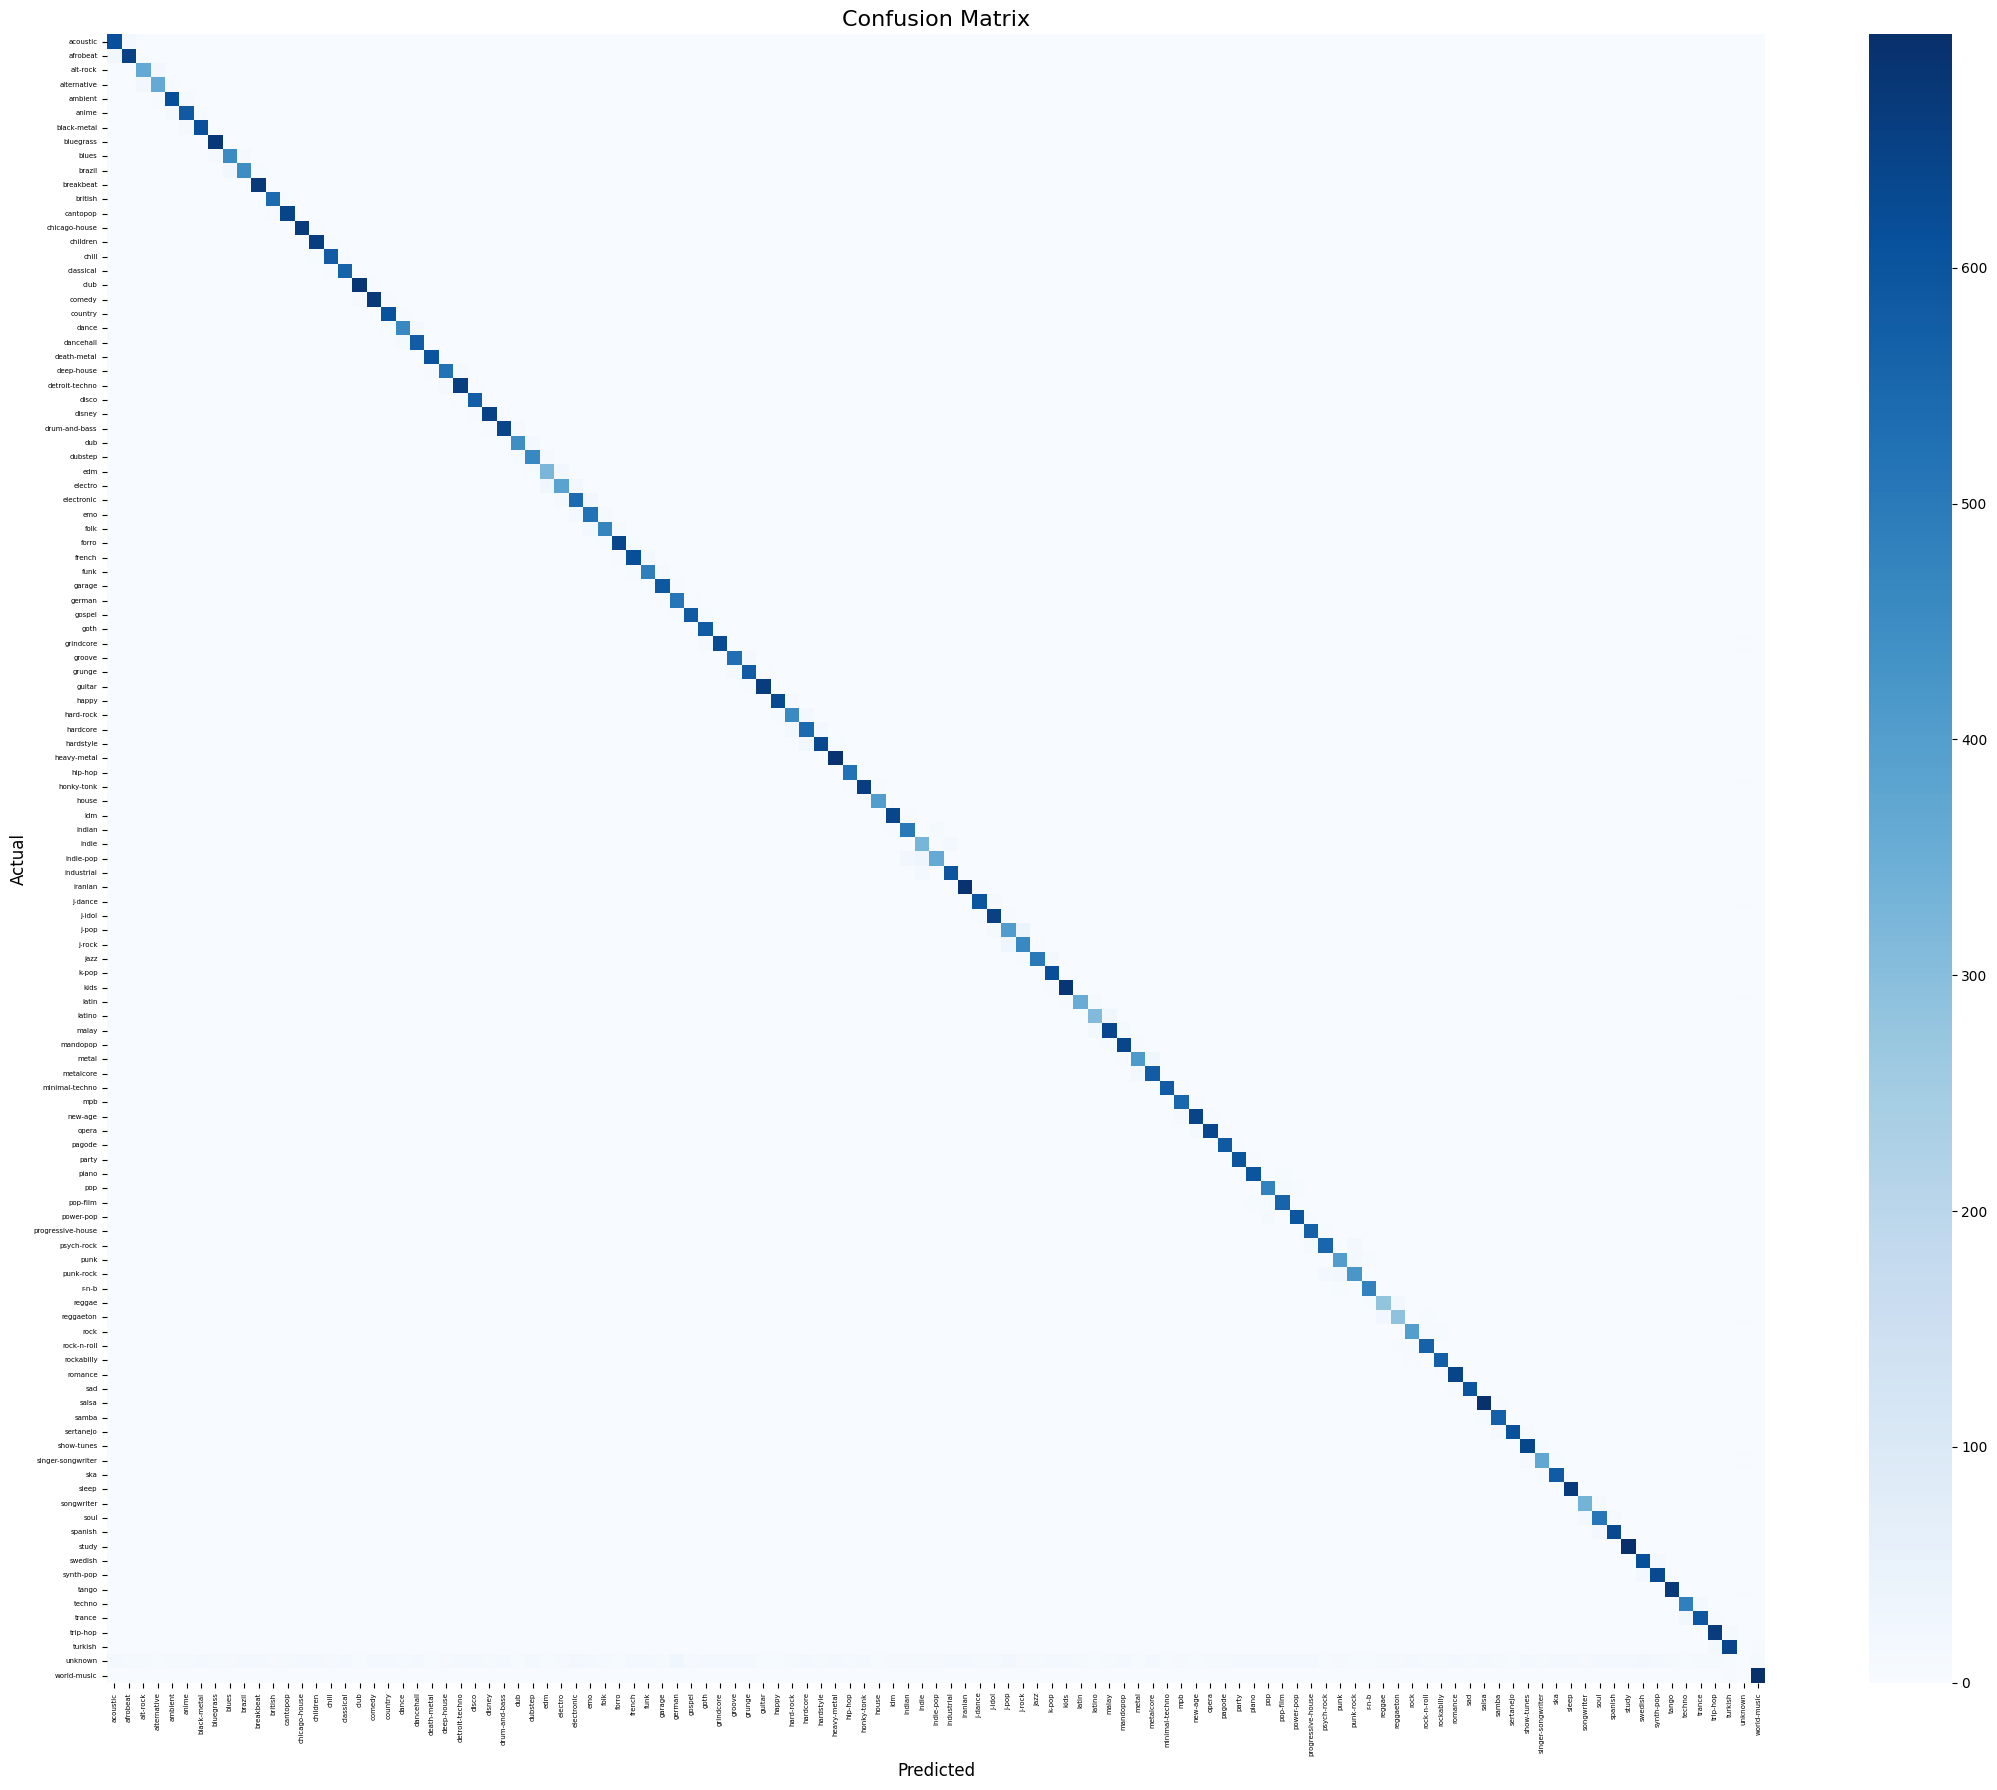

Saved confusion_matrix.png


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, oof_labels)

plt.figure(figsize=(22, 18))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=90, fontsize=5)
plt.yticks(rotation=0, fontsize=5)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Saved confusion_matrix.png")

In [18]:
acc_str  = f"{acc:.4f}"
prec_str = f"{prec:.4f}"
f1_str   = f"{f1:.4f}"

report = f"""
MUSIC GENRE CLASSIFICATION - APPROACH REPORT
Participant:Manasvi Sachin Banthiya
Date: April 2026
Final OOF Accuracy: 0.9498

1. DATA PREPROCESSING
- Removed duplicate track_ids
- Converted explicit column True/False to 1/0
- Filled numeric nulls with median, categorical with unknown
- Clipped outliers: tempo (30-250), loudness (-60 to 5), duration_ms (10k-600k)
- Clipped all audio features to range [0, 1]
- Lowercased and removed special characters from text columns

2. FEATURE ENGINEERING
- Ratio features: energy/danceability, tempo*energy, valence*energy
- Mood features: emotional_intensity, mood_score
- Binary flags: is_rap, is_acoustic, is_instrumental, is_live
- Bucket features: tempo_bucket, energy_bucket, duration_cat, popularity_bucket
- Proxy features: dance_pop_proxy, hiphop_proxy, harmonic_complexity

3. FEATURE REPRESENTATION
- TF-IDF (3000 features) on track_name + artists + album_name
- StandardScaler on all numeric features
- Final matrix: numeric + TF-IDF stacked using scipy hstack

4. MODEL
- Algorithm: LightGBM (LGBMClassifier)
- Cross-validation: StratifiedKFold (3 folds)
- Hyperparameter tuning: Optuna (20 trials)
- Early stopping: 50 rounds

5. EVALUATION (Out-of-Fold - No Data Leakage)
- Fold 1: 0.9493
- Fold 2: 0.9507
- Fold 3: 0.9493
- Final OOF Accuracy : 0.9498
- Accuracy  (weighted): {acc_str}
- Precision (weighted): {prec_str}
- F1 Score  (weighted): {f1_str}

6. FILES SUBMITTED
- notebook.ipynb       : Complete pipeline
- trained_model.pkl    : Saved LightGBM model
- submission.csv       : Test set predictions
- report.txt           : This file
- confusion_matrix.png : Confusion matrix plot
"""

with open('report.txt', 'w') as f:
    f.write(report)

print("report.txt saved!")

report.txt saved!
